# Animal Shelter: Data Preparation

This notebook loads, cleans, and merges the Austin Animal Center 
intake and outcome datasets. The resulting merged DataFrame is 
saved as a pickle file for use in subsequent analysis.

**Data source:** Kaggle — Austin Animal Center Dataset: "https://www.kaggle.com/datasets/thedevastator/austin-animal-center-data"

**Requirements:** Python 3.x, pandas, numpy, matplotlib, seaborn


In [51]:
# Standard library
import datetime
import os

# Third-party libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", "{:,.2f}".format)

**This analysis focuses exclusively on dogs. All other animal types are excluded from the dataset.**

**Intake:** each line of the dataset describes an animal, which has been brought into the shelter.
    
Number of column | Name of column | Datatype | Description
:---|:---|:---|:----  
1  |  `'Animal ID'` | categorical (nominal) | Unique identification number of the animal
2  |  `'Name'` | categorical (`string`) | Name of the animal 
3  |  `'DateTime'` | continuous (`Datetime`) | Date and time when the animal was brought to shelter
4  |  `'MonthYear'` | continuous (`string` + `int`) |Month and Year of intake 
5  |  `'Found Location'` | categorical (`string`) | Adress: found location or home adress
6  |  `'Intake Type'` | categorical (`string`) | How/why animal came to shelter
7  |  `'Intake Condition'` | categorical (`string`) | Health and body condition
8  |  `'Animal Type'` | categorical (`string`) | kind of animal
9  |  `'Sex upon intake'` | categorical (`string`) | gender and sex
10  |  `'Age upon intake'` | categorical (ordinal) (`string`) | age X years/ Y month
11  |  `'Breed'` | categorical (`string`) | Breed of animal
12  |  `'Color'` | categorical (`string`) | Color of fur 


**Outcome:** each line of the dataset describes an animal, which left the shelter.
    
Number of column | Name of column | Datatype | Description
:---|:---|:---|:----  
1  |  `'Animal ID'` | categorical (nominal) | Unique identification number of the animal
2  |  `'Name'` | categorical (`string`) | Name of the animal 
3  |  `'DateTime'` | continuous (`Datetime`) | Date and time when the animal left the shelter
4  |  `'MonthYear'` | continuous (`string` + `int`) |Month and Year of outcome 
5  |  `'Outcome Type'` | categorical (`string`) | How it came out (Adoption...)
6  |  `'Outcome Subtype'` | categorical (`string`) | Further information of how it came out (Foster...)
7  |  `'Animal Type'` | categorical (`string`) | kind of animal
8  |  `'Sex upon Outcome'` | categorical (`string`) | gender and sex
9  |  `'Age upon Outcome'` | categorical (ordinal) (`string`) | age X years/ Y month
10  |  `'Breed'` | categorical (`string`) | Breed of animal
11  |  `'Color'` | categorical (`string`) | Color of fur 


## 1. Load Data

Loading intake and outcome datasets. Filtering for dogs only, 
dropping the Animal Type column. 

The dataset contains 157,628 rows, each of which describes an event associated with an animal. However, this does not mean that there are 157,628 animals, since an animal may be admitted to the shelter more than once. Of these cases, 87,192 involve dogs. Approximately 55% of the full dataset pertains to dogs and is retained for this analysis.

In [2]:
# Load intake data; filter for dogs and drop redundant Animal Type column
df_in = pd.read_csv("data/AustinAnimalCenterIntakes.csv")
print(f"{df_in.shape[0]} animals in data")
df_in = df_in[df_in["Animal Type"] == "Dog"]
df_in = df_in.drop("Animal Type", axis = 1)
print(f"{df_in.shape[0]} dogs in data")
df_in.head()

157628 animals in data
87192 dogs in data


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Sex upon Intake,Age upon Intake,Breed,Color
0,A786884,*Brock,01/03/2019 04:19:00 PM,January 2019,2501 Magin Meadow Dr in Austin (TX),Stray,Normal,Neutered Male,2 years,Beagle Mix,Tricolor
1,A706918,Belle,07/05/2015 12:59:00 PM,July 2015,9409 Bluegrass Dr in Austin (TX),Stray,Normal,Spayed Female,8 years,English Springer Spaniel,White/Liver
2,A724273,Runster,04/14/2016 06:43:00 PM,April 2016,2818 Palomino Trail in Austin (TX),Stray,Normal,Intact Male,11 months,Basenji Mix,Sable/White
4,A682524,Rio,06/29/2014 10:38:00 AM,June 2014,800 Grove Blvd in Austin (TX),Stray,Normal,Neutered Male,4 years,Doberman Pinsch/Australian Cattle Dog,Tan/Gray
5,A743852,Odin,02/18/2017 12:46:00 PM,February 2017,Austin (TX),Owner Surrender,Normal,Neutered Male,2 years,Labrador Retriever Mix,Chocolate


In [3]:
# Load outcome data; apply same filtering as intake (dogs only, drop Animal Type)
df_out = pd.read_csv("data/AustinAnimalCenterOutcomes.csv")
df_out = df_out[df_out["Animal Type"] == "Dog"]
df_out = df_out.drop("Animal Type", axis = 1)
df_out.head(5)

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Age upon Outcome,Breed,Color
1,A776359,Gizmo,07/18/2018 04:02:00 PM,Jul 2018,07/12/2017,Adoption,NaN,Neutered Male,1 year,Chihuahua Shorthair Mix,White/Brown
3,A720371,Moose,02/13/2016 05:59:00 PM,Feb 2016,10/08/2015,Adoption,NaN,Neutered Male,4 months,Anatol Shepherd/Labrador Retriever,Buff
5,A659412,Princess,10/05/2020 02:37:00 PM,Oct 2020,03/24/2013,Adoption,NaN,Spayed Female,7 years,Chihuahua Shorthair Mix,Brown
6,A814515,Quentin,05/06/2020 07:59:00 AM,May 2020,03/01/2018,Adoption,Foster,Neutered Male,2 years,American Foxhound/Labrador Retriever,White/Brown
10,A840370,Tulip,08/19/2021 07:36:00 PM,Aug 2021,08/06/2019,Adoption,NaN,Spayed Female,2 years,Border Collie/Cardigan Welsh Corgi,Black/White


## 2. Data Overview

Custom function to inspect dtypes, missing values, and cardinality.

In [4]:
def get_overview(df):
    '''Return a summary DataFrame with dtype, missing values, and cardinality for each column.
    
    Args:
        df (pd.DataFrame): Input DataFrame to analyze
        
    Returns:
        pd.DataFrame: Summary table with columns [dtype, total, missing_n, missing_%, uniques_n, uniques]
        
    Example:
        >>> get_overview(my_dataframe)
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,                                   # Dtypes
                          'total': df.count(),                                  # number of valid entries
                          'missing_n': df.isna().sum(),                         # Number nan-entries
                          'missing_%': df.isna().mean()*100,                    # Ratio of missing values in %
                          'uniques_n': df.nunique(),                            # Caridinality (Number of unique values)
                          'uniques': [df[col].unique() for col in df.columns]   # List of unique values
                         }))

In [5]:
get_overview(df_in)
get_overview(df_out)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87192,0,0.00,73783,"[A786884, A706918, A724273, A682524, A743852, ..."
Name,str,73426,13766,15.79,17980,"[*Brock, Belle, Runster, Rio, Odin, Beowulf, M..."
DateTime,str,87192,0,0.00,68727,"[01/03/2019 04:19:00 PM, 07/05/2015 12:59:00 P..."
MonthYear,str,87192,0,0.00,123,"[January 2019, July 2015, April 2016, June 201..."
Found Location,str,87192,0,0.00,41624,"[2501 Magin Meadow Dr in Austin (TX), 9409 Blu..."
Intake Type,str,87192,0,0.00,6,"[Stray, Owner Surrender, Public Assist, Abando..."
Intake Condition,str,87192,0,0.00,18,"[Normal, Injured, Pregnant, Sick, Nursing, Age..."
Sex upon Intake,str,87190,2,0.00,5,"[Neutered Male, Spayed Female, Intact Male, In..."
Age upon Intake,str,87191,1,0.00,49,"[2 years, 8 years, 11 months, 4 years, 6 years..."
Breed,str,87192,0,0.00,2554,"[Beagle Mix, English Springer Spaniel, Basenji..."


,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87091,0,0.00,73697,"[A776359, A720371, A659412, A814515, A840370, ..."
Name,str,73355,13736,15.77,17899,"[Gizmo, Moose, Princess, Quentin, Tulip, Fiona..."
DateTime,str,87091,0,0.00,78096,"[07/18/2018 04:02:00 PM, 02/13/2016 05:59:00 P..."
MonthYear,str,87091,0,0.00,123,"[Jul 2018, Feb 2016, Oct 2020, May 2020, Aug 2..."
Date of Birth,str,87091,0,0.00,7717,"[07/12/2017, 10/08/2015, 03/24/2013, 03/01/201..."
Outcome Type,str,87073,18,0.02,9,"[Adoption, Return to Owner, Transfer, Rto-Adop..."
Outcome Subtype,str,28804,58287,66.93,24,"[nan, Foster, Out State, Partner, Aggressive, ..."
Sex upon Outcome,str,87089,2,0.00,5,"[Neutered Male, Spayed Female, Intact Female, ..."
Age upon Outcome,str,87089,2,0.00,49,"[1 year, 4 months, 7 years, 2 years, 9 years, ..."
Breed,str,87091,0,0.00,2556,"[Chihuahua Shorthair Mix, Anatol Shepherd/Labr..."


Despite the *Name* and the *Outcome Subtype*, we have very little missing data

## 3. Data preparation for analysis

- change types
- separate MonthYear
- Age upon Intake/Outcome: to int: in months


Custom function to separate column MonthYear and create two columns (Month, Year)

In [6]:
def separate_month_year(df):
    """Split MonthYear column into separate Month and Year columns.
    
    Converts MonthYear string to datetime, then extracts integer month and year.
    Original MonthYear column is dropped.
    
    Args:
        df (pd.DataFrame): DataFrame containing 'MonthYear' column in format '%B %Y' or '%b %Y'
        
    Returns:
        pd.DataFrame: Copy of input with added Month (int) and Year (int) columns, MonthYear removed
    """
    if "MonthYear" in df:
        df_clean = df.copy()
        #do not give format explicitely, since format_in = %B %Y and format_out = %b %Y pandas does it well
        df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"], 
                                                errors='coerce')
        df_clean["Month"] = df_clean["MonthYear"].dt.month
        df_clean["Year"] = df_clean["MonthYear"].dt.year
        df_clean.drop("MonthYear", inplace = True, axis = 1)
        
        return df_clean
        
    else:
        print("MonthYear is not in df.columns")
        return df



In [8]:
# we ignore the warning - it says that pandas uses a slower but more flexible parser for the datetime-conversion
# we ensured that no NaNs are in the new columns, hence the conversion worked fine
df_out = separate_month_year(df_out)
df_in = separate_month_year(df_in)

/tmp/ipykernel_15026/1624988582.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"],
/tmp/ipykernel_15026/1624988582.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"],


Custom function to convert coulmn DateTime from string into datetime-object 

In [9]:
def date_time(df):
    '''Converts df["DateTime"] into datetime-object
    ARGS:
        df: Dataframe
    RETURN:
        None
    '''
    if "DateTime" in df:
        df_clean = df.copy()
        df_clean["DateTime"] = pd.to_datetime(df_clean["DateTime"], format='%m/%d/%Y %I:%M:%S %p')
        return df_clean
    else:
        print("DateTime is not in df.columns")
        return df

In [10]:
df_out = date_time(df_out)
df_in = date_time(df_in)

Custom function to convert age of the dog from year and month into months.

In [11]:
def convert_age_to_month(df):
    """Convert age strings ('X years', 'Y months') to numeric months.
    
    Extracts the leading numeric value and converts years to months.
    Missing values are handled gracefully.
    
    Args:
        age_series (pd.Series): Column with age strings (e.g., '2 years', '11 months')
        
    Returns:
        pd.Series: Numeric age in months (float), NaN where conversion failed
        
    Example:
        >>> convert_age_to_months(['2 years', '11 months', '5 years'])
        array([24., 11., 60.])
    """
   
    df_month = df.copy()
   
    if "Age upon Intake" in df_month:
        temp_series = df_month["Age upon Intake"].fillna("")
        numbers = temp_series.str.extract(r'(\d+)', expand = False).astype(float)
        ismonth = temp_series.str.contains('month', case=False, na=False)
        df_month['Age upon Intake (months)'] = np.where(
            ismonth,
            numbers,                # If month: keep number
            numbers * 12            # If year: multiply by 12
            )
        df_month = df_month.drop('Age upon Intake', axis = 1)
        return df_month
    elif "Age upon Outcome" in df_month:
        temp_series = df_month["Age upon Outcome"].fillna("")
        numbers = temp_series.str.extract(r'(\d+)', expand = False).astype(float)
        ismonth = temp_series.str.contains('month', case=False, na=False)
        df_month['Age upon Outcome (months)'] = np.where(
            ismonth,
            numbers,                # If month: keep number
            numbers * 12            # If year: multiply by 12
            )
        df_month = df_month.drop('Age upon Outcome', axis = 1)
        return df_month
    else:
        print("Neither Age upon Intake, nor Age upon Outcome are column of df")
        return df

In [12]:
df_in = convert_age_to_month(df_in)
df_out = convert_age_to_month(df_out)

Convert Age in months from float to int. Using Int16 (nullable integer) instead of int allows preserving NaN values.
Standard int dtypes in pandas cannot represent missing values.

In [13]:
df_in["Age upon Intake (months)"] = df_in["Age upon Intake (months)"].astype("Int16")
df_out["Age upon Outcome (months)"] = df_out["Age upon Outcome (months)"].astype("Int16")

In [14]:
get_overview(df_in)
get_overview(df_out)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87192,0,0.00,73783,"[A786884, A706918, A724273, A682524, A743852, ..."
Name,str,73426,13766,15.79,17980,"[*Brock, Belle, Runster, Rio, Odin, Beowulf, M..."
DateTime,datetime64[us],87192,0,0.00,68727,"[2019-01-03 16:19:00, 2015-07-05 12:59:00, 201..."
Found Location,str,87192,0,0.00,41624,"[2501 Magin Meadow Dr in Austin (TX), 9409 Blu..."
Intake Type,str,87192,0,0.00,6,"[Stray, Owner Surrender, Public Assist, Abando..."
Intake Condition,str,87192,0,0.00,18,"[Normal, Injured, Pregnant, Sick, Nursing, Age..."
Sex upon Intake,str,87190,2,0.00,5,"[Neutered Male, Spayed Female, Intact Male, In..."
Breed,str,87192,0,0.00,2554,"[Beagle Mix, English Springer Spaniel, Basenji..."
Color,str,87192,0,0.00,392,"[Tricolor, White/Liver, Sable/White, Tan/Gray,..."
Month,int32,87192,0,0.00,12,"[1, 7, 4, 6, 2, 3, 10, 9, 11, 8, 5, 12]"


,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87091,0,0.00,73697,"[A776359, A720371, A659412, A814515, A840370, ..."
Name,str,73355,13736,15.77,17899,"[Gizmo, Moose, Princess, Quentin, Tulip, Fiona..."
DateTime,datetime64[us],87091,0,0.00,78096,"[2018-07-18 16:02:00, 2016-02-13 17:59:00, 202..."
Date of Birth,str,87091,0,0.00,7717,"[07/12/2017, 10/08/2015, 03/24/2013, 03/01/201..."
Outcome Type,str,87073,18,0.02,9,"[Adoption, Return to Owner, Transfer, Rto-Adop..."
Outcome Subtype,str,28804,58287,66.93,24,"[nan, Foster, Out State, Partner, Aggressive, ..."
Sex upon Outcome,str,87089,2,0.00,5,"[Neutered Male, Spayed Female, Intact Female, ..."
Breed,str,87091,0,0.00,2556,"[Chihuahua Shorthair Mix, Anatol Shepherd/Labr..."
Color,str,87091,0,0.00,393,"[White/Brown, Buff, Brown, Black/White, White/..."
Month,int32,87091,0,0.00,12,"[7, 2, 10, 5, 8, 6, 3, 12, 4, 11, 1, 9]"


### Missing Data Assessment

The most significant missing values appear in:
- **Name (15.8%)**: Animals often enter the shelter unnamed; treated as acceptable
- **Outcome Subtype (66.9%)**: High missing rate indicates many outcomes lack granular classification. This limits detailed subtype analysis but doesn't prevent primary Outcome Type analysis.

Missing values are preserved for now and addressed during specific analyses.

## 4. Data Cleaning

Removing exact duplicate rows (identical values across all columns).
Additionally, identifying animals with multiple shelter visits - these are valid
records representing repeated intake/outcome events, not true duplicates.

In [15]:
# Count and remove exact duplicate rows from both datasets
n_dup_out = df_out.duplicated().sum()
n_dup_in = df_in.duplicated().sum()
print(f"Duplicates removed — df_out: {n_dup_out}, df_in: {n_dup_in}")

df_out = df_out.drop_duplicates()
df_in = df_in.drop_duplicates()

Duplicates removed — df_out: 10, df_in: 16


### Identifying Multi-Visit Animals

Animals may enter and leave the shelter multiple times. These repeated Animal IDs
represent legitimate separate events, not duplicates. Below, we identify and
inspect these cases for the intake dataset (`df_in`).

In [16]:
# Identify animals with multiple intake records
id_counts = df_in['Animal ID'].value_counts()

# Filter for IDs appearing more than once
duplicate_ids = id_counts[id_counts > 1].index
print(f"Animals with multiple intake records: {len(duplicate_ids)}")

# Create a filtered DataFrame for inspection
df_multi_intake = df_in[df_in['Animal ID'].isin(duplicate_ids)].copy()
df_multi_intake = df_multi_intake.sort_values('Animal ID')

print(f"\nTotal rows with multi-visit animals: {len(df_multi_intake)}")
display(df_multi_intake.head(10))

Animals with multiple intake records: 9885

Total rows with multi-visit animals: 23278


,Animal ID,Name,DateTime,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month,Year,Age upon Intake (months)
4368,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2014,84
97793,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,3,2014,72
24086,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2017,120
131442,A245945,Boomer,2015-05-20 22:34:00,7403 Blessing Ave in Austin (TX),Stray,Normal,Neutered Male,Labrador Retriever Mix,Tan,5,2015,180
106423,A245945,Boomer,2014-07-03 17:55:00,Garden And Mildred in Austin (TX),Stray,Normal,Neutered Male,Labrador Retriever Mix,Tan,7,2014,168
866,A287017,Stitch,2015-08-16 12:19:00,6620 Deatonhill Dr in Austin (TX),Stray,Normal,Spayed Female,Chihuahua Shorthair Mix,Black/White,8,2015,168
127907,A287017,Stitch,2014-12-12 07:04:00,Lazy Oaks /Westgate William Cannon in Austin (TX),Stray,Aged,Spayed Female,Chihuahua Shorthair Mix,Black/White,12,2014,156
34608,A307010,Cooper,2016-09-25 12:51:00,Freidrich Lane And St Elmo Rd in Austin (TX),Stray,Normal,Neutered Male,Beagle Mix,Tricolor,9,2016,156
42612,A307010,Cooper,2017-06-01 11:47:00,806 Castle Ridge in Austin (TX),Owner Surrender,Normal,Neutered Male,Beagle Mix,Tricolor,6,2017,168
61795,A322813,Tyson,2015-03-05 14:49:00,Austin (TX),Public Assist,Normal,Neutered Male,Rottweiler Mix,Black/Brown,3,2015,132


Applying the same identification logic to the outcome dataset (`df_out`):

In [17]:
id_counts_out = df_out['Animal ID'].value_counts()

duplicate_ids_out = id_counts_out[id_counts_out > 1].index

print(f"Number of at least doubled IDs in df_out: {len(duplicate_ids_out)}")

df_duplicates_out = df_out[df_out['Animal ID'].isin(duplicate_ids_out)].copy()

df_duplicates_out = df_duplicates_out.sort_values('Animal ID')

print(f"\nNumber of rows in new df_out: {len(df_duplicates_out)}")
display(df_duplicates_out.head(10))

Number of at least doubled IDs in df_out: 9881

Number of rows in new df_out: 23265


,Animal ID,Name,DateTime,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Breed,Color,Month,Year,Age upon Outcome (months)
125158,A006100,Scamp,2014-03-08 17:10:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,3,2014,72
61555,A006100,Scamp,2014-12-20 16:35:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2014,84
110187,A006100,Scamp,2017-12-07 00:00:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2017,120
98468,A245945,Boomer,2014-07-04 15:26:00,05/23/2000,Return to Owner,NaN,Neutered Male,Labrador Retriever Mix,Tan,7,2014,168
75479,A245945,Boomer,2015-05-25 11:49:00,05/23/2000,Transfer,Partner,Neutered Male,Labrador Retriever Mix,Tan,5,2015,180
26463,A287017,Stitch,2014-12-12 16:49:00,05/13/2001,Return to Owner,NaN,Spayed Female,Chihuahua Shorthair Mix,Black/White,12,2014,156
77255,A287017,Stitch,2015-08-16 13:31:00,05/13/2001,Return to Owner,NaN,Spayed Female,Chihuahua Shorthair Mix,Black/White,8,2015,168
41456,A307010,Cooper,2016-09-28 09:36:00,03/04/2003,Return to Owner,NaN,Neutered Male,Beagle Mix,Tricolor,9,2016,156
102980,A307010,Cooper,2017-06-05 15:11:00,03/04/2003,Return to Owner,NaN,Neutered Male,Beagle Mix,Tricolor,6,2017,168
58129,A322813,Tyson,2015-12-24 14:31:00,03/26/2003,Return to Owner,NaN,Neutered Male,Rottweiler Mix,Black/Brown,12,2015,144


In [18]:
# Assign sequential visit numbers per animal, ordered by DateTime
# (already converted to datetime in Section 3)
df_in['Number of Intake'] = df_in.groupby('Animal ID')['DateTime'].rank(method='min').astype('Int64')
df_out['Number of Outcome'] = df_out.groupby('Animal ID')['DateTime'].rank(method='min').astype('Int64')

### Target Variable: `Left Shelter`

Creating a boolean target column indicating whether each dog has a corresponding
outcome record. Dogs present in `df_out` are marked `True` (left the shelter);
those without an outcome remain `False` (still in shelter at data export).

In [19]:
# Create target variable: True if the animal has an outcome record
outcome_ids = df_out['Animal ID'].unique()
df_in['Left Shelter'] = df_in['Animal ID'].isin(outcome_ids)

print(f"Unique outcome IDs: {len(outcome_ids)}")
print(f"Intake records with matching outcome: {df_in['Left Shelter'].sum()}")

Unique outcome IDs: 73697
Intake records with matching outcome: 86709


### Progress Summary

At this point, the dataset has been cleaned, typed, and enriched with derived
columns. The next steps focus on encoding categorical variables for the
predictive model.

**Model Objective:** Predict shelter stay duration (`Time in shelter`) based on
intake-level features: Intake Condition, Intake Type, and Sex/Status.

### Encoding Sex and Reproductive Status

The `Sex upon Intake/Outcome` column combines two attributes: reproductive status
(Neutered/Spayed/Intact/Unknown) and biological sex (Male/Female). We:
1. Inspect unique values
2. Impute missing entries with `"Missing"`
3. Split the combined string into separate `Status` and `Sex` columns

In [20]:
df_out["Sex upon Outcome"].unique()

<StringArray>
['Neutered Male', 'Spayed Female', 'Intact Female',   'Intact Male',
       'Unknown',             nan]
Length: 6, dtype: str

In [21]:
df_in["Sex upon Intake"] = df_in["Sex upon Intake"].fillna("Missing")
df_out["Sex upon Outcome"] = df_out["Sex upon Outcome"].fillna("Missing")

In [22]:
def separate_sex(df, col):
    """Split a combined sex/status column into separate Status and Sex columns.
    
    Expected input format: '<Status> <Sex>' (e.g., 'Neutered Male').
    Single-word values (e.g., 'Unknown') produce NaN in the Sex column,
    which should be handled by the caller.
    
    Note: The original column is preserved. Drop it separately if needed.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        col (str): Column name to split
        
    Returns:
        pd.DataFrame: Copy with added 'Status' and 'Sex' columns
    """
    df_clean = df.copy()
    split_cols = df_clean[col].str.split(" ", n=1, expand = True)
    
    df_clean["Status"] = split_cols[0]    
    df_clean["Sex"] = split_cols[1]

    return df_clean

In [23]:
df_in = separate_sex(df_in, "Sex upon Intake")
df_out = separate_sex(df_out, "Sex upon Outcome")

In [24]:
df_in["Sex"]=df_in["Sex"].fillna("Missing")
df_out["Sex"]=df_out["Sex"].fillna("Missing")

### 5. New merged dataframe
Bring the incoming and outgoing dogs together for further analysis

In [25]:
# Rename shared columns to distinguish intake vs. outcome
df_in = df_in.rename(columns={
    'Month': 'Month_in',
    'Year': 'Year_in',
    "Sex" : "Sex_in",
    "Status" : "Status_in",
    "DateTime" : "DateTime_in"
})


df_out = df_out.rename(columns={
    'Month': 'Month_out',
    'Year': 'Year_out',
    "Sex" : "Sex_out",
    "Status" : "Status_out",
    "DateTime" : "DateTime_out"
})
# Assign event sequence per animal to enable correct intake↔outcome pairing
df_in['event_id'] = df_in.groupby('Animal ID').cumcount() + 1
df_out['event_id'] = df_out.groupby('Animal ID').cumcount() + 1

# Left join: retain all intake records even without matching outcome
merged_df = pd.merge(
    df_in,
    df_out[['Animal ID', 'event_id', 'Month_out', 'Year_out', 'Age upon Outcome (months)', "DateTime_out",'Number of Outcome', "Outcome Type" ,	"Outcome Subtype", "Status_out","Sex_out"]],
    on=['Animal ID', 'event_id'],
    how='left'
)

# Animals without outcome records get 0 for outcome count
merged_df['Number of Outcome'] = merged_df['Number of Outcome'].fillna(0).astype(int)

# Drop the temporary pairing key
merged_df = merged_df.drop(columns=['event_id'])

merged_df = merged_df.sort_values(by=['Animal ID', 'Month_in', 'Year_in']).reset_index(drop=True)
display(merged_df.head())

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month_in,...,Sex_in,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out
0,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,3,...,Male,3.00,"2,014.00",72,2014-03-08 17:10:00,1,Return to Owner,NaN,Neutered,Male
1,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,...,Male,12.00,"2,014.00",84,2014-12-20 16:35:00,2,Return to Owner,NaN,Neutered,Male
2,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,...,Male,12.00,"2,017.00",120,2017-12-07 00:00:00,3,Return to Owner,NaN,Neutered,Male
3,A047759,Oreo,2014-04-02 15:55:00,Austin (TX),Owner Surrender,Normal,Neutered Male,Dachshund,Tricolor,4,...,Male,4.00,"2,014.00",120,2014-04-07 15:12:00,1,Transfer,Partner,Neutered,Male
4,A134067,Bandit,2013-11-16 09:02:00,12034 Research Blvd in Austin (TX),Public Assist,Injured,Neutered Male,Shetland Sheepdog,Brown/White,11,...,Male,11.00,"2,013.00",192,2013-11-16 11:54:00,1,Return to Owner,NaN,Neutered,Male


In [26]:
get_overview(merged_df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87176,0,0.00,73783,"[A006100, A047759, A134067, A141142, A163459, ..."
Name,str,73411,13765,15.79,17980,"[Scamp, Oreo, Bandit, Bettie, Sasha, Pep, Boti..."
DateTime_in,datetime64[us],87176,0,0.00,68727,"[2014-03-07 14:26:00, 2014-12-19 10:21:00, 201..."
Found Location,str,87176,0,0.00,41624,"[8700 Research in Austin (TX), 8700 Research B..."
Intake Type,str,87176,0,0.00,6,"[Public Assist, Stray, Owner Surrender, Euthan..."
Intake Condition,str,87176,0,0.00,18,"[Normal, Injured, Aged, Sick, Medical, Other, ..."
Sex upon Intake,str,87176,0,0.00,6,"[Neutered Male, Spayed Female, Intact Female, ..."
Breed,str,87176,0,0.00,2554,"[Spinone Italiano Mix, Dachshund, Shetland She..."
Color,str,87176,0,0.00,392,"[Yellow/White, Tricolor, Brown/White, Black/Wh..."
Month_in,int32,87176,0,0.00,12,"[3, 12, 4, 11, 9, 10, 2, 8, 7, 6, 5, 1]"


In [28]:
def make_column_stay_in_shelter(df):
    """Calculate the duration of each dog's stay in the shelter.

    Computes the difference between outcome and intake datetime.
    Missing outcome datetimes are treated as 'still in shelter' (filled with
    current timestamp). Same-day midnight outcomes are set to 5 hours.
    Negative durations (outcome before intake) are set to NaT.

    Args:
        df (pd.DataFrame): Merged DataFrame with 'DateTime_in' and 'DateTime_out' columns

    Returns:
        pd.DataFrame: Copy of input with added 'Time in shelter' column (pd.Timedelta)
    """
    df_new = df.copy()
    # Missing outcome datetimes are assumed to indicate the animal is still in shelter;
    # fill with current timestamp as proxy
    df_new["Temp"] = df_new["DateTime_out"].fillna(pd.to_datetime(datetime.datetime.now()))
    df_new["Time in shelter"] = df_new["Temp"] - df_new["DateTime_in"]
    #check whether left on same day, but hour of left = 0:00 (i suggest just not written down)
    #this is the special case. If a time is given, this suggestion is less valid 
    same_day = df_new["DateTime_in"].dt.date == df_new["Temp"].dt.date
    is_midnight = df_new["Temp"].dt.time == datetime.time(0, 0)
    mask_special_case = same_day & is_midnight
    df_new.loc[mask_special_case, "Time in shelter"] = pd.Timedelta(hours=5)
    
    # Negative durations indicate data errors (outcome before intake); set to NaT
    mask_negative = df_new["Time in shelter"] < pd.Timedelta(0)
    df_new.loc[mask_negative, "Time in shelter"] = pd.NaT
    
    # drop temporary column
    df_new = df_new.drop("Temp", axis = 1)
    return df_new

In [29]:
merged_df = merged_df.drop("Sex upon Intake", axis = 1)

In [30]:
merged_df = make_column_stay_in_shelter(merged_df)

In [31]:
merged_df.head()

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
0,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,3,2014,...,3.00,"2,014.00",72,2014-03-08 17:10:00,1,Return to Owner,NaN,Neutered,Male,1 days 02:44:00
1,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,12,2014,...,12.00,"2,014.00",84,2014-12-20 16:35:00,2,Return to Owner,NaN,Neutered,Male,1 days 06:14:00
2,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Spinone Italiano Mix,Yellow/White,12,2017,...,12.00,"2,017.00",120,2017-12-07 00:00:00,3,Return to Owner,NaN,Neutered,Male,0 days 05:00:00
3,A047759,Oreo,2014-04-02 15:55:00,Austin (TX),Owner Surrender,Normal,Dachshund,Tricolor,4,2014,...,4.00,"2,014.00",120,2014-04-07 15:12:00,1,Transfer,Partner,Neutered,Male,4 days 23:17:00
4,A134067,Bandit,2013-11-16 09:02:00,12034 Research Blvd in Austin (TX),Public Assist,Injured,Shetland Sheepdog,Brown/White,11,2013,...,11.00,"2,013.00",192,2013-11-16 11:54:00,1,Return to Owner,NaN,Neutered,Male,0 days 02:52:00


### Data Quality Investigation: Negative Shelter Durations

During validation, some records showed negative shelter duration (outcome before intake).
Investigating the case "Lil Baby" (two different animals sharing the same name)
revealed that the merge logic pairs correctly by Animal ID and event sequence.

In [32]:
merged_df[merged_df["Time in shelter"] < pd.Timedelta(0)]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter


In [33]:
df_in[df_in["Name"] == "Lil Baby"]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month_in,Year_in,Age upon Intake (months),Number of Intake,Left Shelter,Status_in,Sex_in,event_id
20175,A876313,Lil Baby,2023-03-13 11:10:00,Community First Village in Austin (TX),Stray,Normal,Intact Female,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,8,1,True,Intact,Female,1
145289,A889898,Lil Baby,2023-10-19 18:47:00,Austin (TX),Owner Surrender,Normal,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,2,True,Spayed,Female,1
153958,A889898,Lil Baby,2023-09-29 11:28:00,5105 Acorn Cove in Austin (TX),Public Assist,Normal,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,9,2023,120,1,True,Spayed,Female,2


In [34]:
df_out[df_out["Name"] == "Lil Baby"]

,Animal ID,Name,DateTime_out,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Breed,Color,Month_out,Year_out,Age upon Outcome (months),Number of Outcome,Status_out,Sex_out,event_id
60029,A889898,Lil Baby,2023-10-03 18:08:00,09/29/2013,Return to Owner,NaN,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,1,Spayed,Female,1
108458,A876313,Lil Baby,2023-03-14 14:21:00,06/13/2022,Return to Owner,NaN,Intact Female,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,9,1,Intact,Female,1
154142,A889898,Lil Baby,2023-10-21 13:12:00,09/29/2013,Adoption,NaN,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,2,Spayed,Female,2


In [35]:
merged_df[merged_df["Name"]=="Lil Baby"]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
83980,A876313,Lil Baby,2023-03-13 11:10:00,Community First Village in Austin (TX),Stray,Normal,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,...,3.00,"2,023.00",9,2023-03-14 14:21:00,1,Return to Owner,NaN,Intact,Female,1 days 03:11:00
86467,A889898,Lil Baby,2023-09-29 11:28:00,5105 Acorn Cove in Austin (TX),Public Assist,Normal,Yorkshire Terrier/Chihuahua Shorthair,Black/White,9,2023,...,10.00,"2,023.00",120,2023-10-21 13:12:00,2,Adoption,NaN,Spayed,Female,22 days 01:44:00
86468,A889898,Lil Baby,2023-10-19 18:47:00,Austin (TX),Owner Surrender,Normal,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,...,10.00,"2,023.00",120,2023-10-03 18:08:00,1,Return to Owner,NaN,Spayed,Female,NaT


### Exploratory Visualization

Distribution of outcome counts per animal - showing how many times dogs
typically cycle through the shelter system.

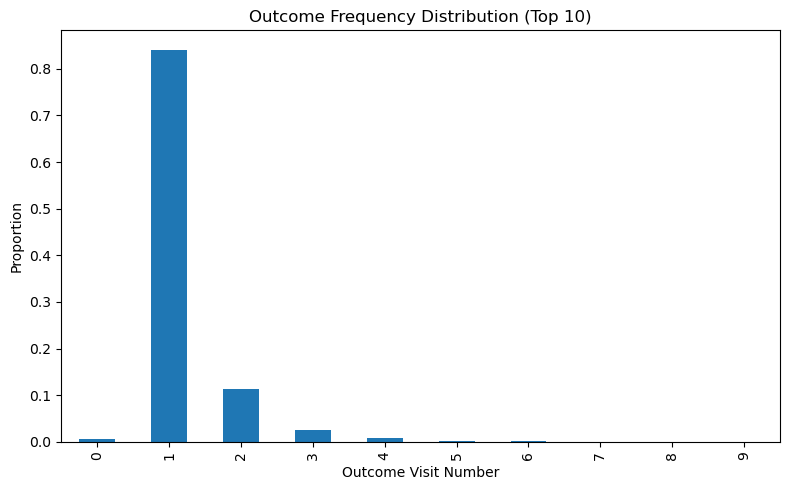

In [36]:
# Distribution of outcome frequency per animal visit
outcome_dist = merged_df["Number of Outcome"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
outcome_dist.head(10).plot(kind="bar", ax=ax)
ax.set_title("Outcome Frequency Distribution (Top 10)")
ax.set_xlabel("Outcome Visit Number")
ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

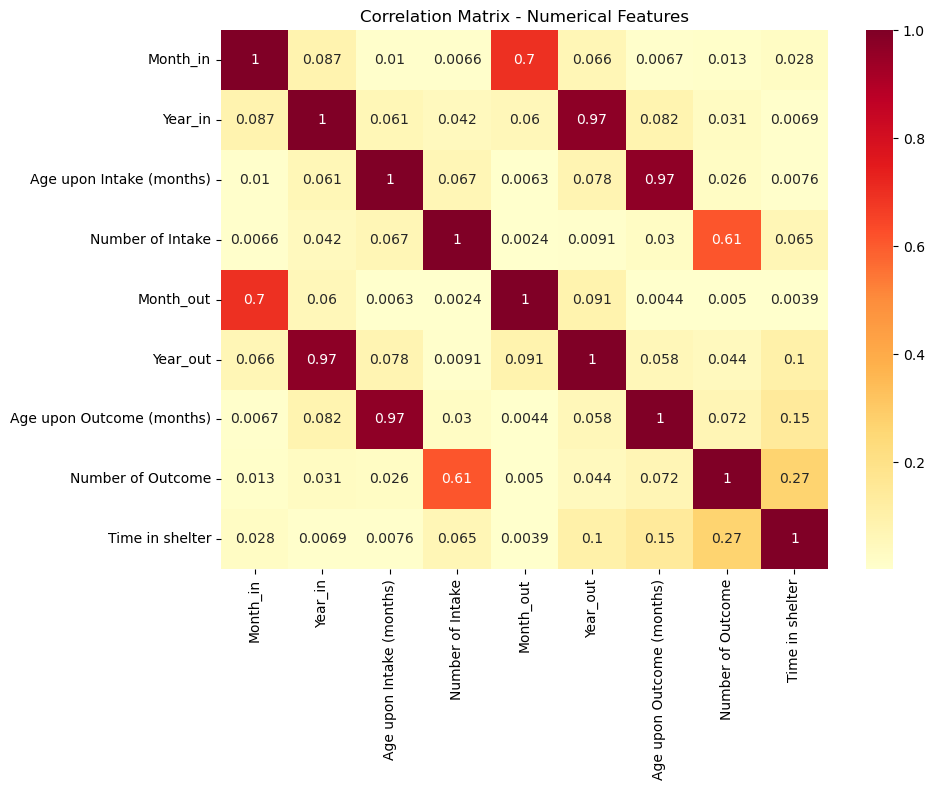

In [38]:
# Correlation heatmap of numerical features
# Absolute values highlight relationship strength regardless of direction

num_df = merged_df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr().abs(), annot=True, cmap='YlOrRd')
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()


In [42]:
def plot_numerical(col, data = num_df, save_plot = False):
    """Plot histogram, boxplot, and KDE for a single numerical column.

    Creates a 3-panel figure showing distribution (boxplot, histogram with
    KDE overlay, and pure kernel density estimate). Useful for exploring
    outliers and distribution shape before modeling.

    Args:
        col (str): Column name to visualize
        data (pd.DataFrame): Input DataFrame (default: num_df)
        save_plot (bool): Save plot to disk as 'numplot_{column}.png' (default: False)
        
    Returns:
        None: Displays plot inline; saves if save_plot=True
    """
    if col not in data.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame")
    
    if data[col].isna().all():
        print(f"Warning: Column '{col}' contains only NaN values. Skipping.")
        return
    fig, axes = plt.subplots(nrows=1, ncols = 3, figsize = (18,4))

    # Panel 1: Boxplot
    sns.boxplot(data = data,y = col, ax = axes[0])
    axes[0].set_title("Boxplot")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Panel 2: Histogram with Density
    axes[1].hist(data[col], bins=30, alpha=0.5, color='steelblue', edgecolor='white')
    axes[1].set_title("Histogram")
    axes[1].set_xlabel("")
    axes[1].grid(axis='y', alpha=0.3)
    
    # Panel 3: KDE
    sns.kdeplot(data=data[col], ax=axes[2])
    axes[2].set_title("Density")
    axes[2].set_xlabel("")
    # Layout & Save
    plt.suptitle(f"Distribution Analysis: {col}", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_plot:
        fig.savefig(f'plots/numplot_{col}.png', dpi=150, bbox_inches='tight')
        
    plt.show()

### Exploring Numerical Feature Distributions

Visualizing the distribution patterns for selected numerical features.
Three complementary views per feature:
- **Boxplot**: Identifies outliers and median spread
- **Histogram**: Shows frequency distribution
- **KDE**: Smooth density estimation for pattern recognition

> **Note**: Features like 'Month_in' and 'Number of Outcome' may be treated
> as categorical despite numeric encoding. Interpret with caution.

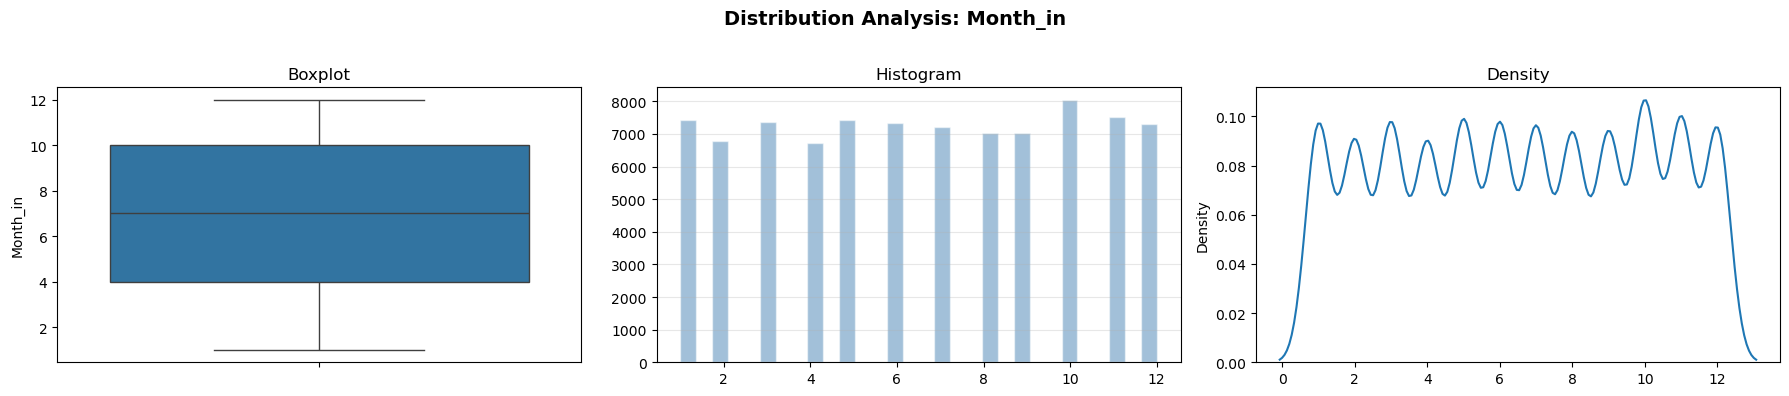

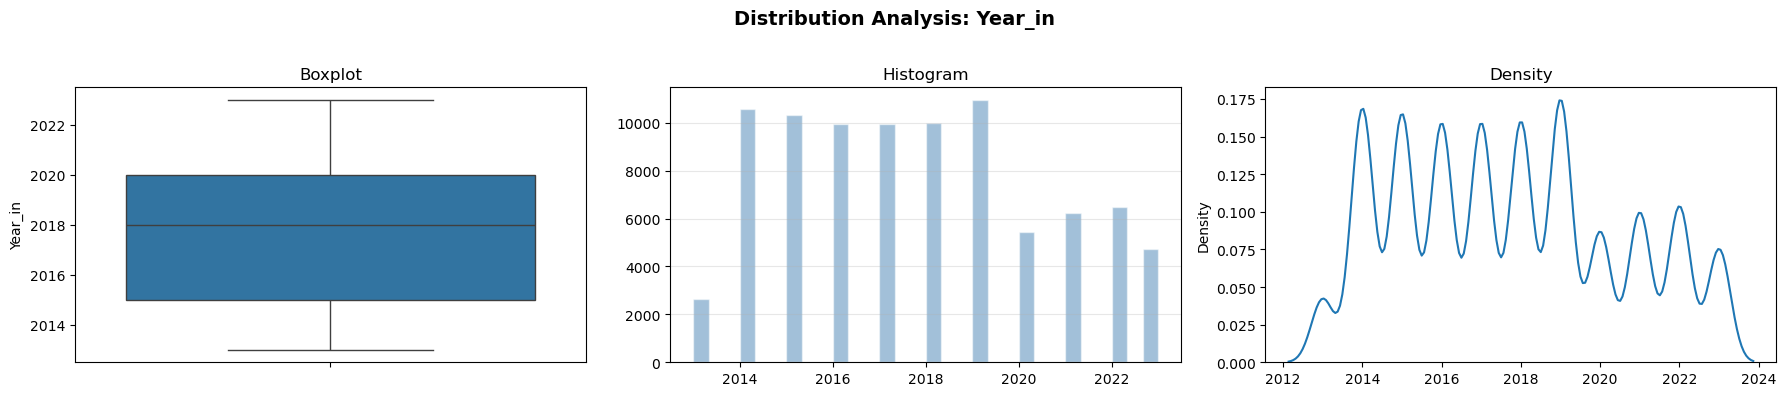

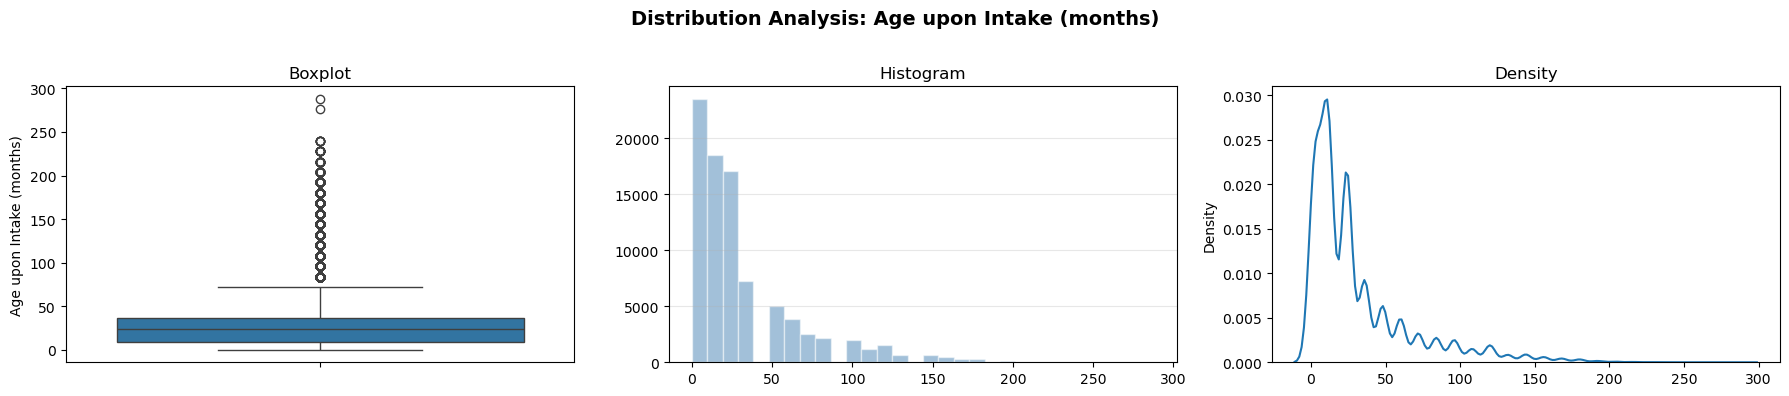

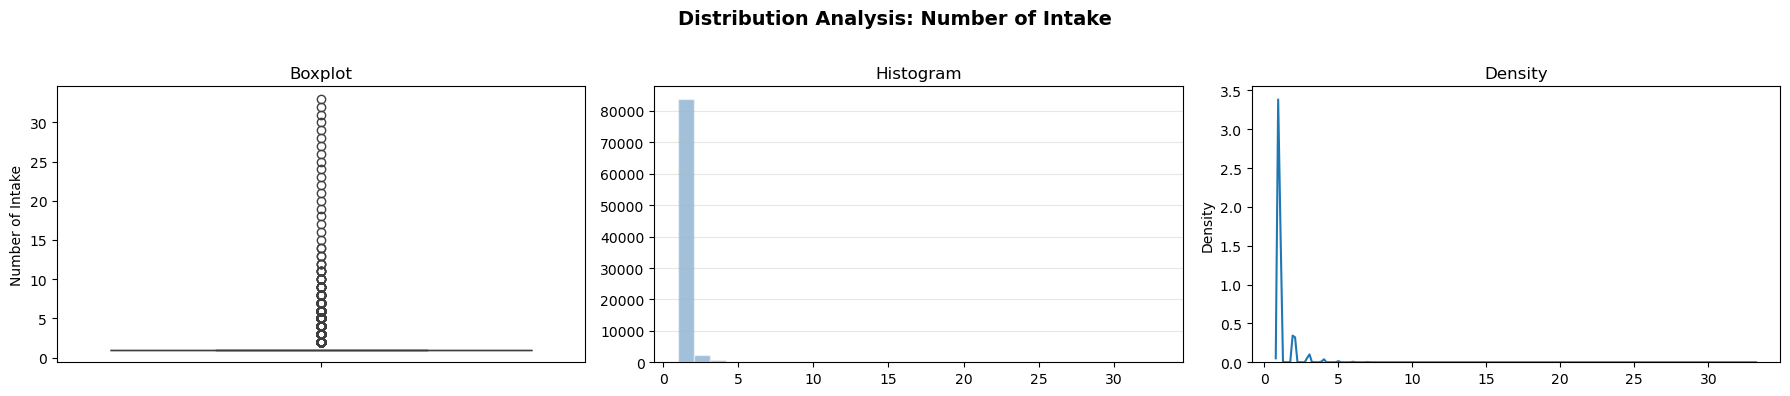

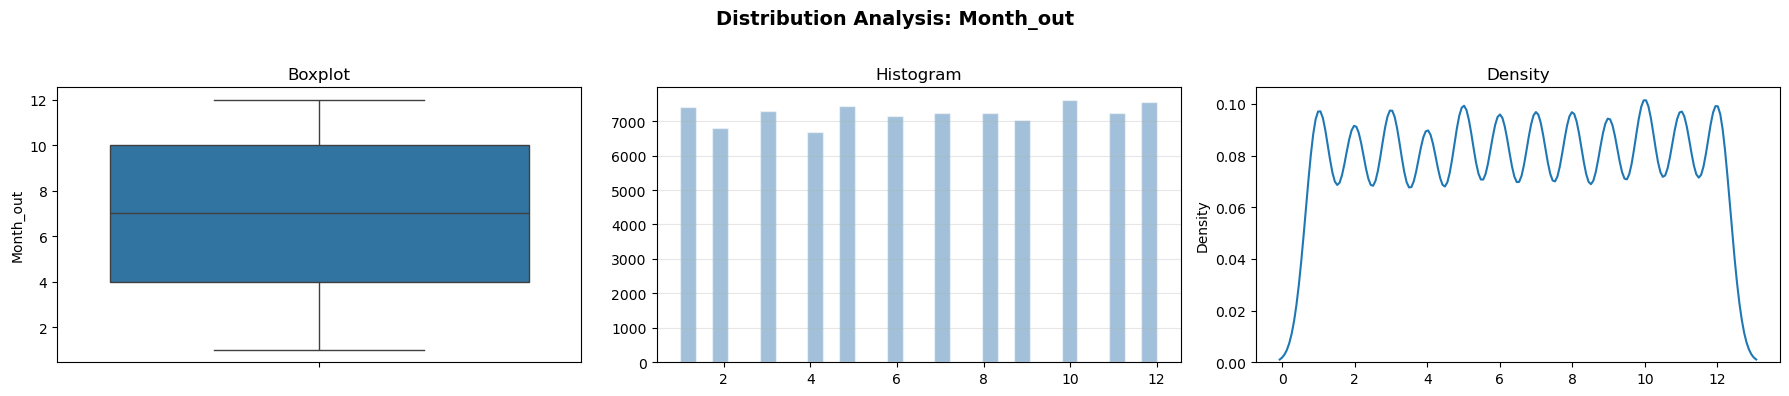

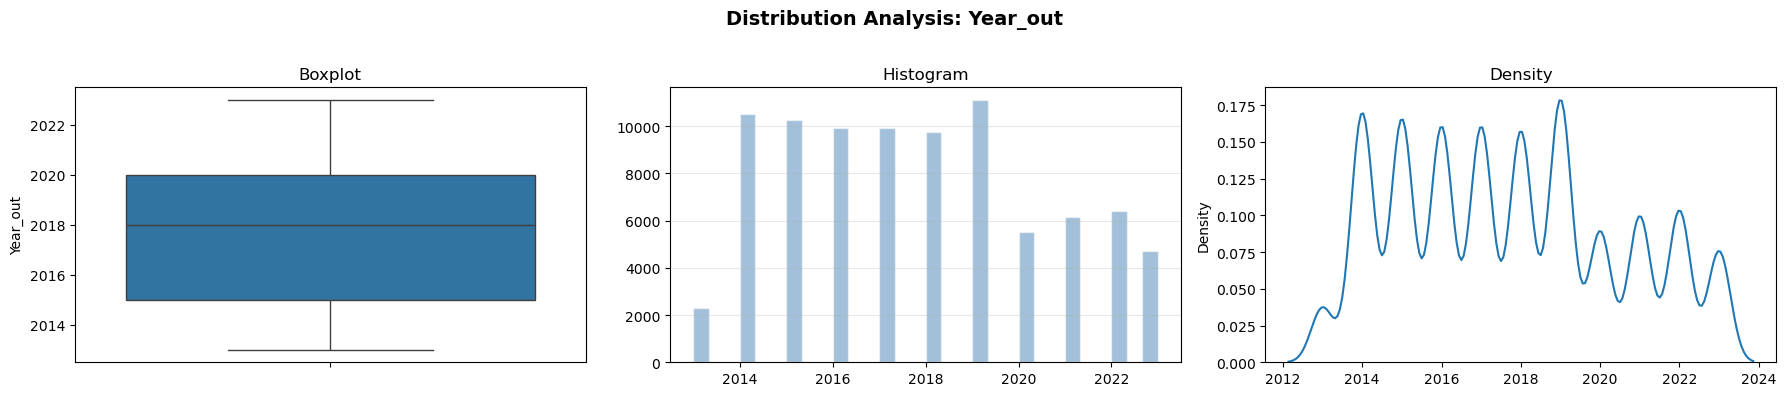

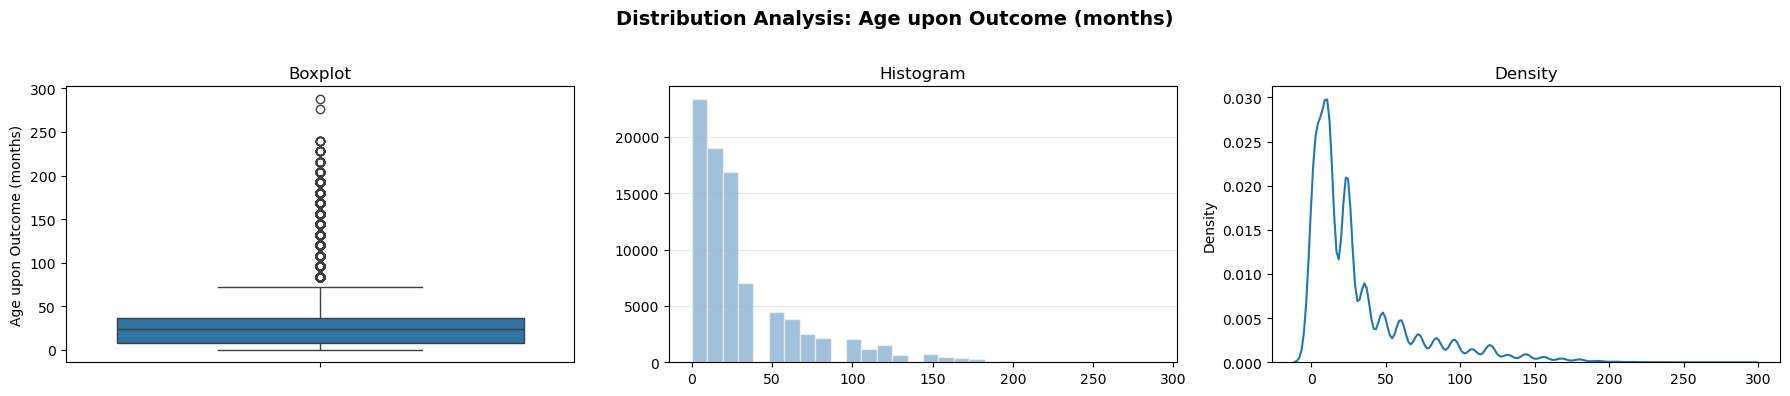

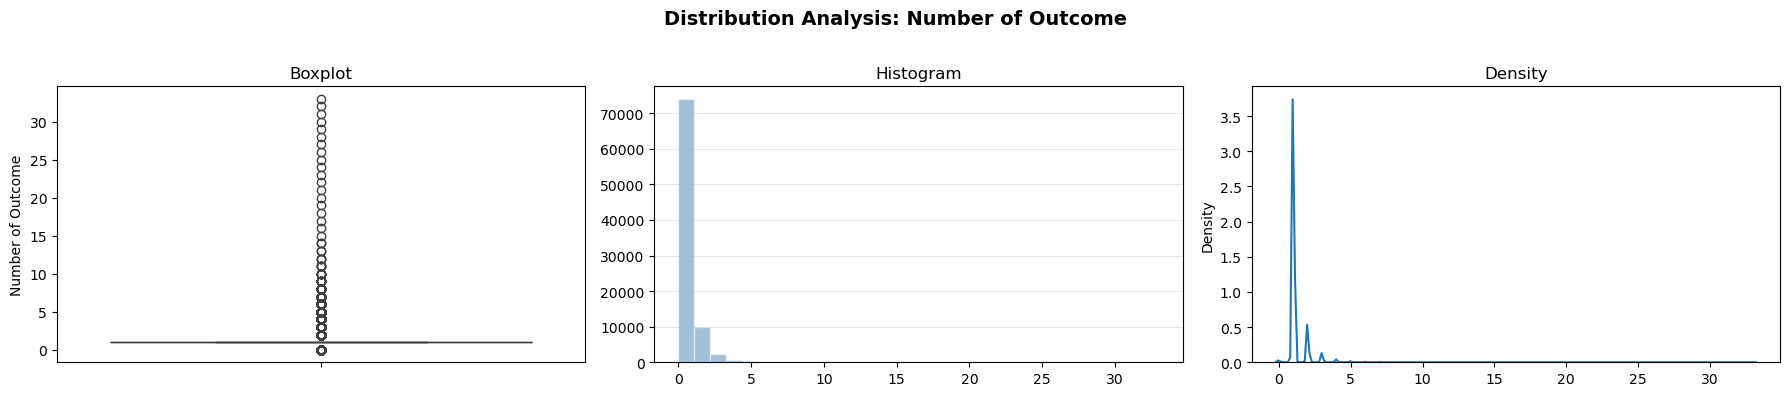

In [43]:
numcol = ['Month_in', 'Year_in', 'Age upon Intake (months)', 'Number of Intake',
       'Month_out', 'Year_out', 'Age upon Outcome (months)',
       'Number of Outcome']

for num in numcol:
    plot_numerical(num)


### Outlier Handling

The distribution includes extreme stays (e.g. administrative errors or rare medical cases).
To visualize the typical shelter stay effectively, we cap the x-axis at 250 days.
Records > 250 days are retained in the data but excluded from visualization clarity.

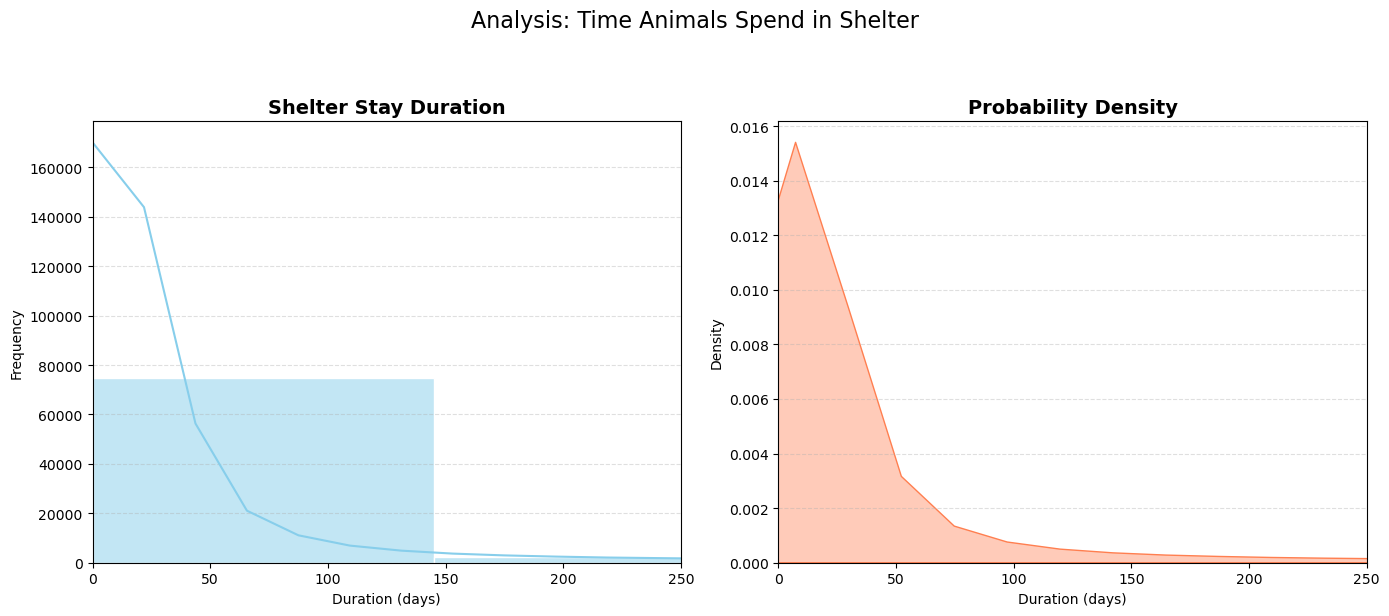

In [44]:
# Extract shelter duration in days from timedelta column
# Filtering out negative durations (data errors) beforehand is assumed
stay_days = merged_df["Time in shelter"].dt.total_seconds() / (3600 * 24)

# Define visualization layout
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# 1. Histogram with Density Curve (using seaborn for consistent scaling)
# Capping x-axis at 250 days to focus on majority and hide extreme outliers
sns.histplot(
    stay_days, 
    bins=30, 
    kde=True, 
    color='skyblue', 
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_title("Shelter Stay Duration", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Duration (days)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 250)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# 2. Pure Kernel Density Estimate (KDE)
sns.kdeplot(stay_days, ax=axes[1], fill=True, color='coral', alpha=0.4)
axes[1].set_title("Probability Density", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Duration (days)")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, 250)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("Analysis: Time Dogs Spend in Shelter", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Prevent overlap with suptitle

# Show plot (no display_data metadata clutter)
plt.show()

### Categorical Distribution Analysis

**Note on target imbalance:** The `Left` variable is heavily imbalanced
(~97% positive). Raw proportional plots therefore show near-uniform bars
across categories. To reveal meaningful patterns, deviations from the
baseline rate are visualized instead.

This imbalance also has implications for predictive modeling - consider
class weighting or resampling strategies.

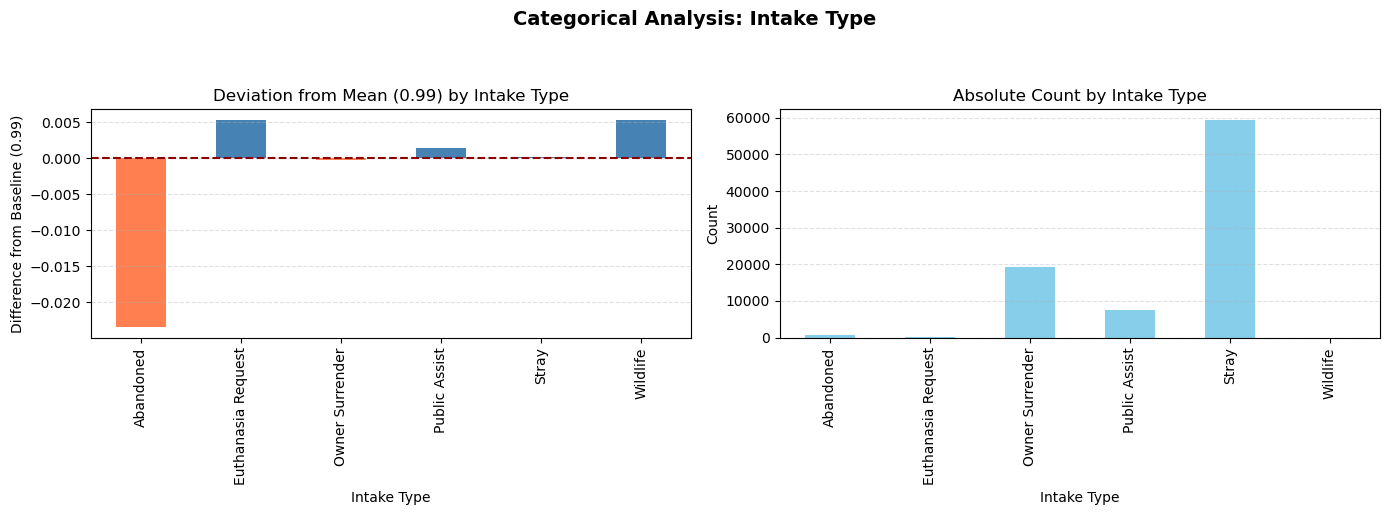

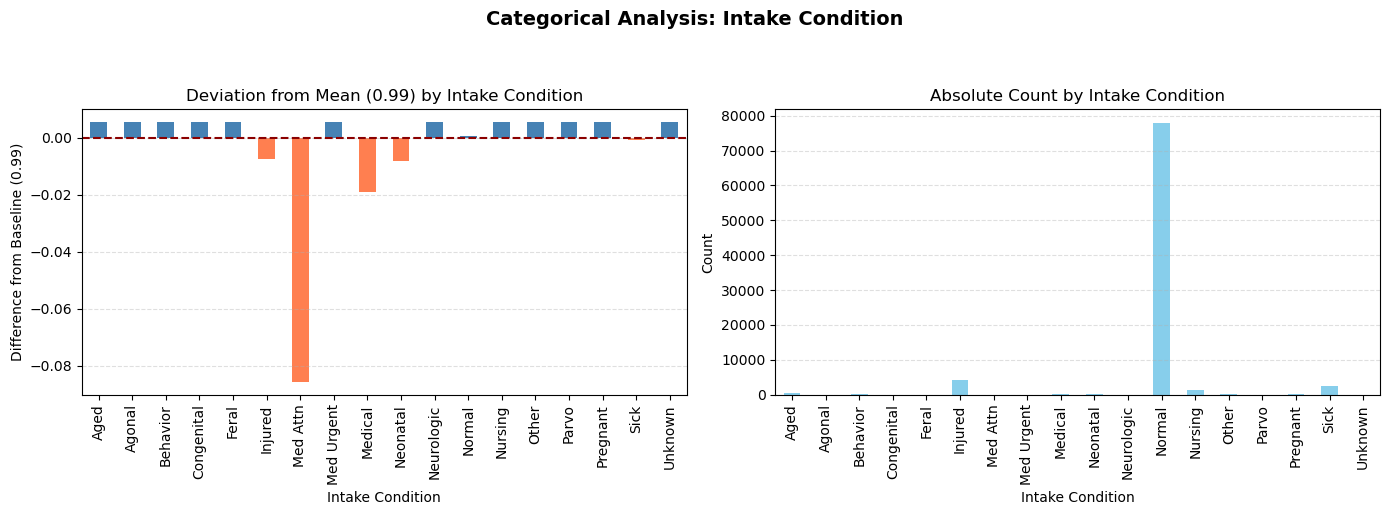

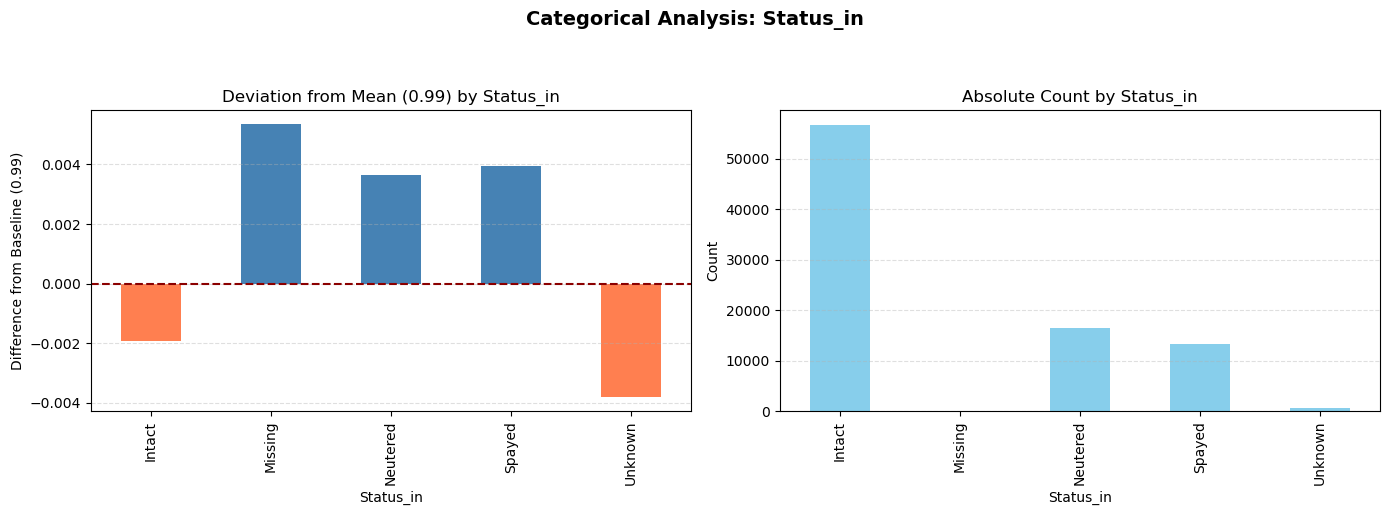

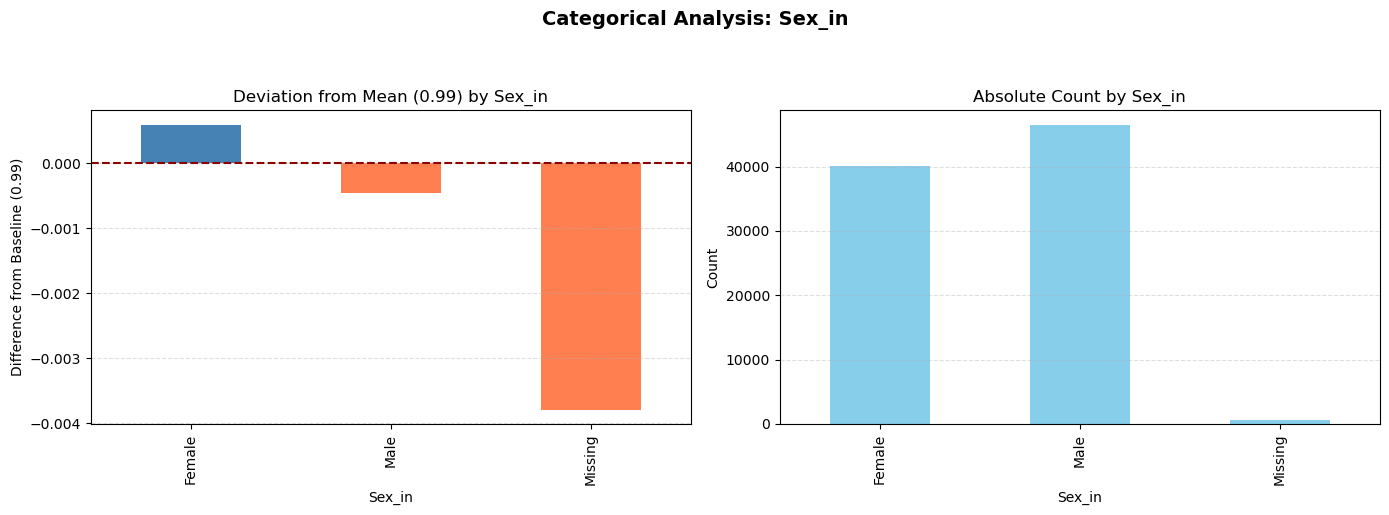

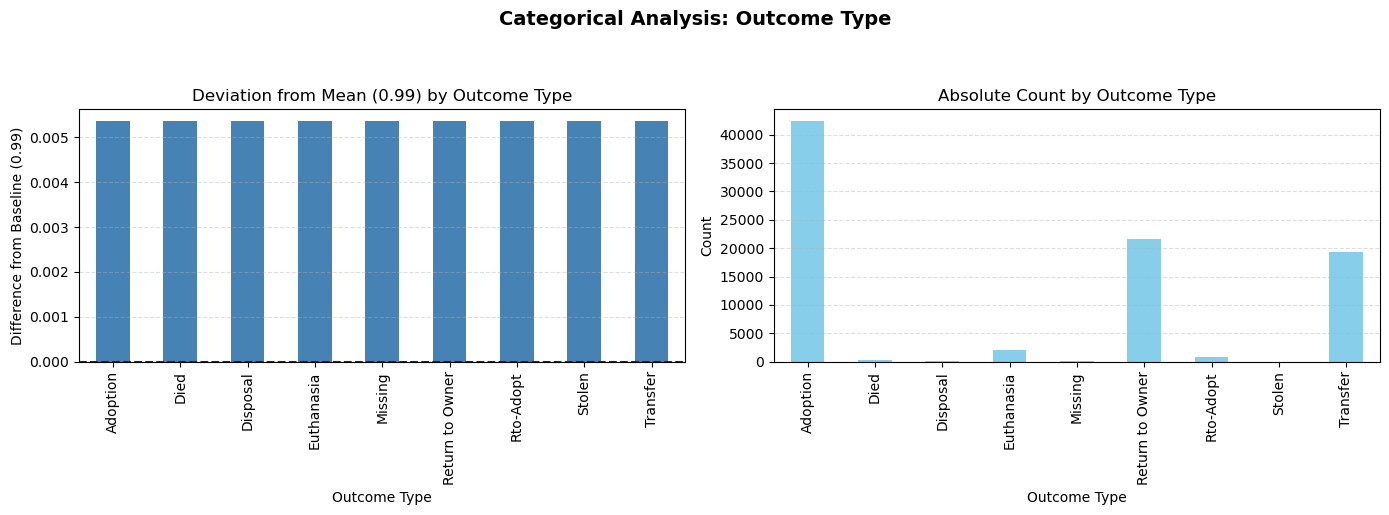

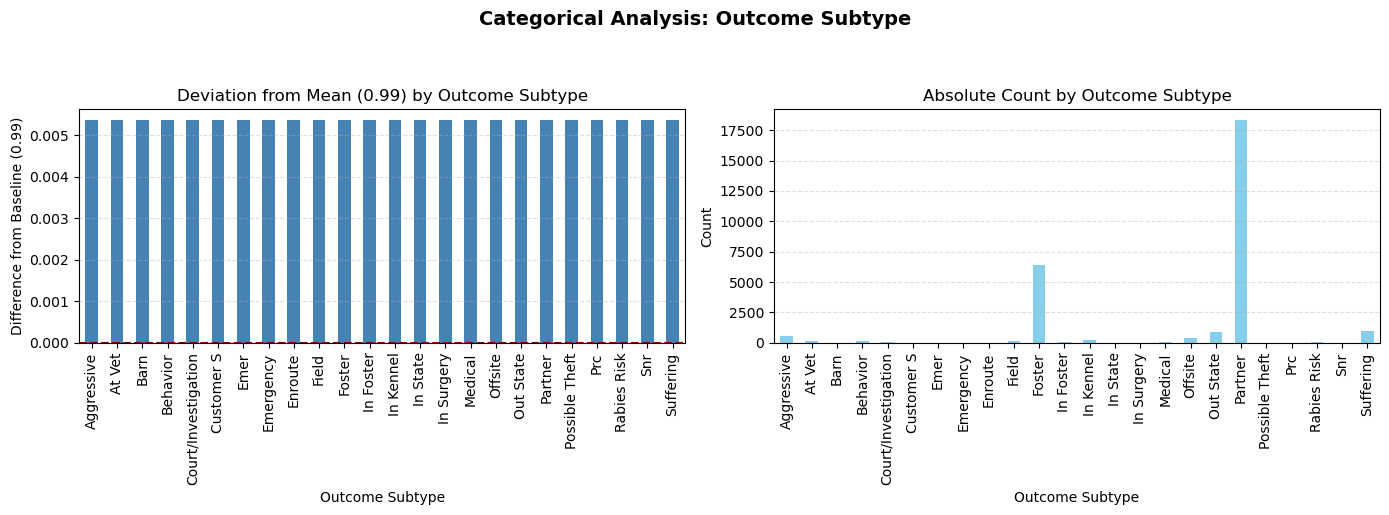

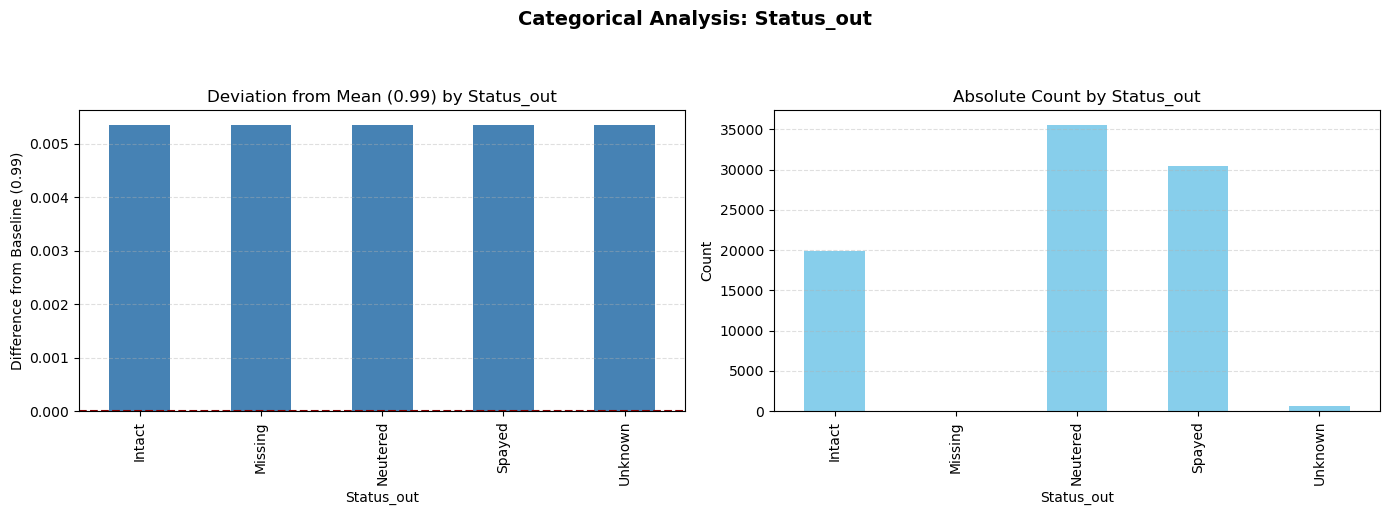

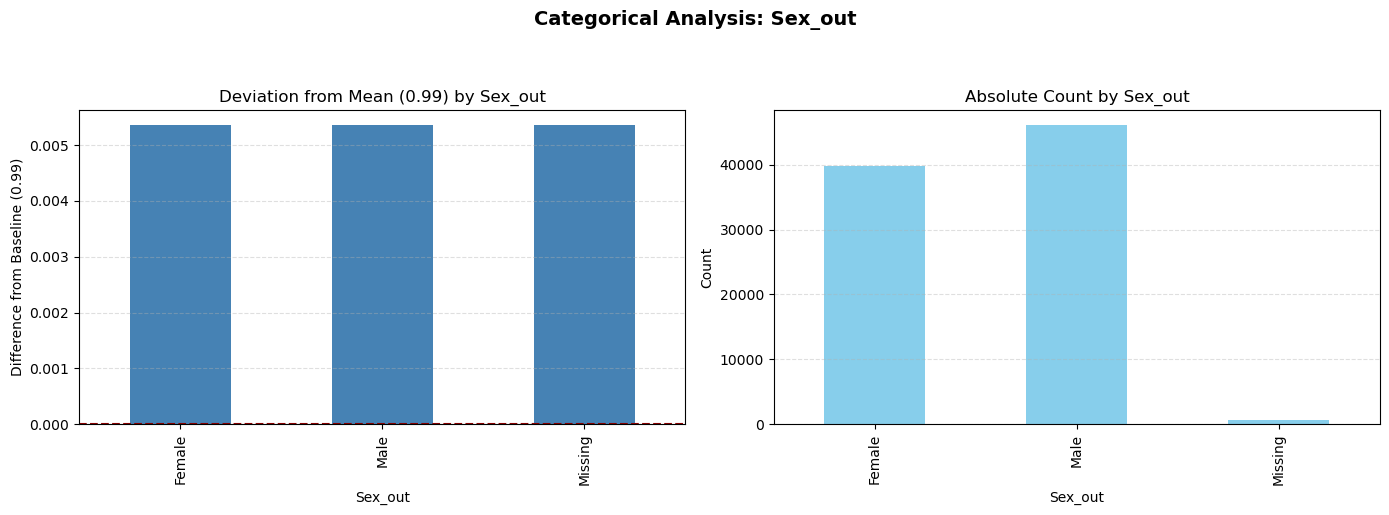

In [48]:
catcols = [
    'Intake Type', 'Intake Condition', 'Status_in', 'Sex_in',
    'Outcome Type', 'Outcome Subtype', 'Status_out', 'Sex_out'
]

def plot_categorical(col, data=merged_df, key="Left Shelter", highlight=True, save_plot=False):
    """Plot relative and absolute distributions of a categorical column.

    Left panel: Normalized crosstab showing proportion of target class
    per category, with mean reference line for quick comparison.
    Right panel: Absolute counts for assessing sample size per category.

    Args:
        col (str): Categorical column to analyze
        data (pd.DataFrame): Input DataFrame (default: merged_df)
        key (str): Target column for relative distribution (default: 'Left')
        highlight: Value in target column to highlight (default: True)
        save_plot (bool): Save figure as 'catplot_{col}.png' (default: False)

    Returns:
        None: Displays or saves plot
    """
    if col not in data.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame")

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # --- Left: Deviation from mean (much more informative) ---
    crosstab_rel = pd.crosstab(
        index=data[col], columns=data[key], normalize='index'
    )

    if highlight in crosstab_rel.columns:
        avg = data[key].mean()
        deviation = crosstab_rel[highlight] - avg
    
        deviation.plot(kind='bar', ax=axes[0], color=['coral' if v < 0 else 'steelblue' 
                    for v in deviation], legend=False)
        axes[0].axhline(0, color='darkred', linestyle='--', linewidth=1.5)
        axes[0].set_title(f'Deviation from Mean ({avg:.2f}) by {col}')
        axes[0].set_ylabel(f'Difference from Baseline ({avg:.2f})')
        axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # --- Right: Absolute counts ---
    counts = data[col].value_counts().sort_index()
    counts.plot(kind='bar', ax=axes[1], color='skyblue')
    axes[1].set_title(f'Absolute Count by {col}')
    axes[1].set_ylabel('Count')
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    plt.suptitle(f'Categorical Analysis: {col}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_plot:
        fig.savefig(f'catplot_{col}.png', dpi=150, bbox_inches='tight')

    plt.show()


# Generate all categorical plots
for col in catcols:
    plot_categorical(col)

## 6. Conclusions & Next Steps

The analysis reveals a high placement rate (~97%), which limits the usefulness of
binary prediction models for "Leaving Shelter" as a target variable. Given this
imbalance, two alternative modeling directions are recommended:

1. **Duration Prediction Model**: Predict `Time in shelter` (regression) using
   intake-level features (Condition, Type, Age, Sex). This provides actionable
   insights for shelter operations without being affected by class imbalance.

2. **Unsupervised Learning**: Cluster animals based on intake profiles to
   identify subgroups (e.g., high-risk categories, typical stay lengths).

The dataset is now fully cleaned, transformed, and enriched. All subsequent
analysis and modeling will build upon `merged_df`. To avoid re-running the
pipeline, the DataFrame is persisted below.

In [52]:
# Persist the processed DataFrame for downstream analysis
# Location: data/ directory in repository root
# Format: pickle (.pkl) — efficient for Python, NOT human-readable
merged_df.to_pickle("data/shelter_data.pkl")

print(f"Dataset saved: {merged_df.shape[0]:,} rows × {merged_df.shape[1]} columns")
print(f"File size: {(os.path.getsize('data/shelter_data.pkl') / 1024 ** 2):.2f} MB")

Dataset saved: 87,176 rows × 25 columns
File size: 15.11 MB
